Data: Open University Learning Analytics Dataset (OULAD)

https://www.kaggle.com/datasets/anlgrbz/student-demographics-online-education-dataoulad/data?select=studentAssessment.csv

In [2]:
import dowhy
from dowhy import CausalModel
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import graphviz as gr
from matplotlib import style
from matplotlib import pyplot as plt
style.use("fivethirtyeight")

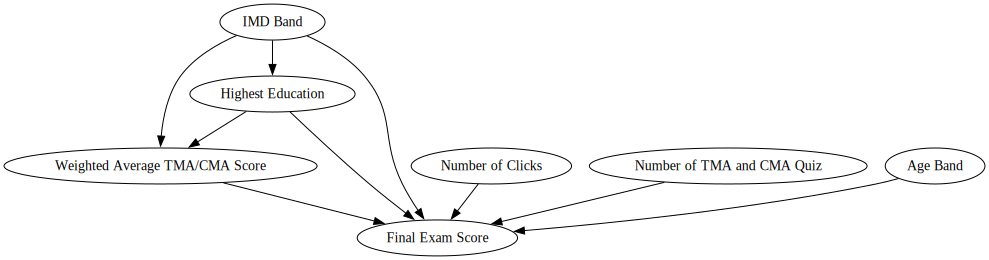

In [25]:
g = gr.Digraph()

g.edge('IMD Band', 'Highest Education')
g.edge('IMD Band', 'Weighted Average TMA/CMA Score')

# g.edge('Region', 'Highest Education')
# g.edge('Region', 'Weighted Average TMA/CMA Score')


g.edge('Highest Education', 'Weighted Average TMA/CMA Score')
g.edge('Highest Education', 'Final Exam Score')

g.edge('IMD Band', 'Final Exam Score')
# g.edge('Region', 'Final Exam Score')
g.edge('Weighted Average TMA/CMA Score', 'Final Exam Score')

g.edge('Number of Clicks', 'Final Exam Score')
g.edge('Number of TMA and CMA Quiz', 'Final Exam Score')
g.edge('Age Band', 'Final Exam Score')
# g.edge('Different course', 'Final Score')

g

In [11]:
courses = pd.read_csv('Data/courses.csv')
assessments = pd.read_csv('Data/assessments.csv')
stu_assess = pd.read_csv('Data/studentAssessment.csv')
regist = pd.read_csv('Data/studentRegistration.csv')
vle = pd.read_csv('Data/studentVle.csv')
stu_info = pd.read_csv('Data/studentInfo.csv')

print(courses.head())
print(assessments.head())
print(stu_assess.head())
print(regist.head())
print(vle.head())
print(stu_info.head())

  code_module code_presentation  module_presentation_length
0         AAA             2013J                         268
1         AAA             2014J                         269
2         BBB             2013J                         268
3         BBB             2014J                         262
4         BBB             2013B                         240
  code_module code_presentation  id_assessment assessment_type   date  weight
0         AAA             2013J           1752             TMA   19.0    10.0
1         AAA             2013J           1753             TMA   54.0    20.0
2         AAA             2013J           1754             TMA  117.0    20.0
3         AAA             2013J           1755             TMA  166.0    20.0
4         AAA             2013J           1756             TMA  215.0    30.0
   id_assessment  id_student  date_submitted  is_banked  score
0           1752       11391              18          0   78.0
1           1752       28400              22  

In [58]:
# only keep students that did not drop out 
undrop_stu = regist[regist['date_unregistration'].isnull()]

# find the total click of the course materials at the student, and course level
undrop_vle = undrop_stu.merge(vle, how = 'left', on = ['id_student', 'code_module', 'code_presentation'])
crs_lvl_vle = undrop_vle.groupby(['id_student', 'code_module', 'code_presentation'])['sum_click'].sum().reset_index(name ='tot_click')

# total course data
undrop_stu_score = undrop_stu.merge(stu_assess[stu_assess['is_banked'] == 0], how = 'left', on = ['id_student'])
crs_score = undrop_stu_score.merge(assessments, on = ['id_assessment','code_module', 'code_presentation'])

# tma_cma course_data summarized at the student-course level
tma_cma_crs_score = crs_score[crs_score['assessment_type'].isin(['TMA', 'CMA'])].copy()

tma_cma_crs_score['weighted_score'] = tma_cma_crs_score['weight']*0.01 * tma_cma_crs_score['score']
tma_cma_crs_lvl = tma_cma_crs_score.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    tot_quiz_weight = ('weight', 'sum'),
    quiz_weighted_avg_score = ('weighted_score', 'sum'),
    cnt_quiz = ('id_assessment','count')
).reset_index()
tma_cma_crs_lvl = tma_cma_crs_lvl[tma_cma_crs_lvl['tot_quiz_weight']== 100]


# final exam course_data summarized at the student-course level
exam_score = crs_score[crs_score['assessment_type']=='Exam'].copy()[['id_student', 'code_module', 'code_presentation', 'score']].rename(columns = {'score': 'final_score'})
# exam_score['weighted_score'] = exam_score['weight']*0.01 * exam_score['score']
# exam_score_lvl = exam_score.groupby(['id_student', 'code_module', 'code_presentation']).agg(
#     tot_weight = ('weight', 'sum'),
#     weighted_avg_score = ('weighted_score', 'sum'),
#     cnt_quiz = ('id_assessment','count')
# ).reset_index()



# combine the final exam score and the quiz score


In [6]:
stu_info.groupby(['age_band'])['id_student'].count().reset_index(name = 'cnt_stu')
young_stu = stu_info[(stu_info['age_band'] =='0-35') & (stu_info['highest_education'] =='A Level or Equivalent')]

print(young_stu.groupby('num_of_prev_attempts').count())

                      code_module  code_presentation  id_student  gender  \
num_of_prev_attempts                                                       
0                            9393               9393        9393    9393   
1                             988                988         988     988   
2                             198                198         198     198   
3                              32                 32          32      32   
4                              11                 11          11      11   
5                               2                  2           2       2   

                      region  highest_education  imd_band  age_band  \
num_of_prev_attempts                                                  
0                       9393               9393      9227      9393   
1                        988                988       965       988   
2                        198                198       195       198   
3                         32        

5
